# Methodology Visualizations

This notebook generates the figures used in docs/methodology.md.
All outputs are saved to docs/images/.

Run cells in order — each cell depends on the ones above it.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

# Load all the data
precincts = gpd.read_file('../data/processed/travis_precincts_2020.gpkg')
districts = gpd.read_file('../data/processed/travis_districts_2026.gpkg')
blocks = gpd.read_file('../data/processed/travis_blocks_2020.gpkg')
results = pd.read_csv('../data/processed/travis_interpolated_results.csv')
weights = pd.read_csv('../data/processed/travis_population_weights.csv')

blocks['total'] = pd.to_numeric(blocks['total'], errors='coerce')

print("All data loaded successfully")
print(f"Precincts: {len(precincts)}, Districts: {len(districts)}, Blocks: {len(blocks)}")

All data loaded successfully
Precincts: 247, Districts: 7, Blocks: 16906


## Load old district boundaries (PlanC2193 — used 2022 and 2024 elections)

In [2]:
old_districts = gpd.read_file('zip://../data/raw/boundaries/PLANC2193.zip!PLANC2193/PLANC2193.shp')

print(f"Total districts: {len(old_districts)}")
print(f"CRS: {old_districts.crs.to_epsg()}")
print(f"Columns: {list(old_districts.columns)}")

# Filter to districts touching Travis County
old_travis_districts = old_districts[old_districts.intersects(precincts.unary_union)]
print(f"Old districts touching Travis County: {len(old_travis_districts)}")
print(f"District numbers: {sorted(old_travis_districts['District'].values)}")

Total districts: 38
CRS: 3081
Columns: ['District', 'geometry']
Old districts touching Travis County: 7
District numbers: [10, 17, 21, 27, 31, 35, 37]


## Find a good example precinct to illustrate the split
We need a precinct that straddles two districts with a meaningful population split.
Precinct 4530341 splits exactly 50/50 between Districts 10 and 37.

In [3]:
# Find precincts that split across multiple districts
split_precincts = weights[weights.groupby('old_precinct_id')['old_precinct_id'].transform('count') > 1]
split_precincts_summary = weights[weights['old_precinct_id'].isin(split_precincts['old_precinct_id'])].groupby('old_precinct_id').agg(
    num_districts=('new_district_id', 'count'),
    max_weight=('weight', 'max'),
    min_weight=('weight', 'min')
).reset_index()

# Find interesting splits — not 99/1 but more like 60/40 to 85/15
interesting = split_precincts_summary[
    (split_precincts_summary['num_districts'] == 2) &
    (split_precincts_summary['min_weight'] > 0.10)
].sort_values('min_weight', ascending=False)

print(f"Interesting split precincts: {len(interesting)}")
print(interesting.head(10))

Interesting split precincts: 56
     old_precinct_id  num_districts  max_weight  min_weight
87           4530341              2    0.500000    0.500000
11           4530119              2    0.500000    0.500000
61           4530305              2    0.500000    0.500000
73           4530325              2    0.509896    0.490104
54           4530266              2    0.545705    0.454295
113          4530406              2    0.562728    0.437272
47           4530250              2    0.593665    0.406335
60           4530304              2    0.607334    0.392666
121          4530418              2    0.609929    0.390071
119          4530416              2    0.622688    0.377312


## Draft: side by side district comparison (Travis County only)
Note: superseded by the full redistricting comparison figure below.
Keeping for reference.

<ipython-input-4-d730b8c948f1>:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  old_legend = [mpatches.Patch(color=old_colors[i], edgecolor='#5F5E5A',
<ipython-input-4-d730b8c948f1>:45: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  new_legend = [mpatches.Patch(color=new_colors[i], edgecolor='#E24B4A',


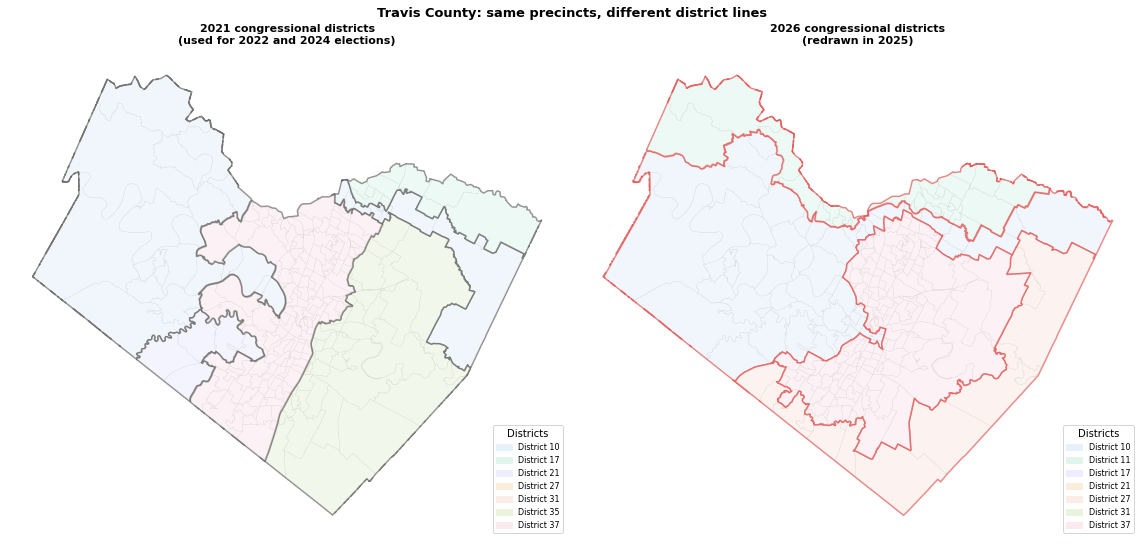

In [4]:
import matplotlib.cm as cm

# Get Travis County bounds
minx, miny, maxx, maxy = precincts.total_bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05

# Color palettes for old and new districts
old_colors = ['#E6F1FB', '#E1F5EE', '#EEEDFE', '#FAEEDA', '#FAECE7', '#EAF3DE', '#FBEAF0']
new_colors = ['#E6F1FB', '#E1F5EE', '#EEEDFE', '#FAEEDA', '#FAECE7', '#EAF3DE', '#FBEAF0']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1 — Old map
ax1 = axes[0]
precincts.plot(ax=ax1, color='white', edgecolor='#B4B2A9', linewidth=0.3)
old_sorted = old_travis_districts.sort_values('District').reset_index(drop=True)
for i, (idx, row) in enumerate(old_sorted.iterrows()):
    gpd.GeoDataFrame([row], geometry='geometry', crs=old_travis_districts.crs).clip(
        gpd.GeoDataFrame([{'geometry': precincts.unary_union}], geometry='geometry', crs=precincts.crs)
    ).plot(ax=ax1, color=old_colors[i], edgecolor='#5F5E5A', linewidth=1.5, alpha=0.6)
ax1.set_xlim(minx - pad_x, maxx + pad_x)
ax1.set_ylim(miny - pad_y, maxy + pad_y)
ax1.set_axis_off()
ax1.set_title('2021 congressional districts\n(used for 2022 and 2024 elections)',
              fontsize=11, fontweight='bold', pad=10)
old_legend = [mpatches.Patch(color=old_colors[i], edgecolor='#5F5E5A',
              label=f"District {row['District']}") 
              for i, (_, row) in enumerate(old_sorted.iterrows())]
ax1.legend(handles=old_legend, loc='lower right', fontsize=8, title='Districts')

# Panel 2 — New map
ax2 = axes[1]
precincts.plot(ax=ax2, color='white', edgecolor='#B4B2A9', linewidth=0.3)
new_sorted = districts.sort_values('District').reset_index(drop=True)
for i, (idx, row) in enumerate(new_sorted.iterrows()):
    gpd.GeoDataFrame([row], geometry='geometry', crs=districts.crs).clip(
        gpd.GeoDataFrame([{'geometry': precincts.unary_union}], geometry='geometry', crs=precincts.crs)
    ).plot(ax=ax2, color=new_colors[i], edgecolor='#E24B4A', linewidth=1.5, alpha=0.6)
ax2.set_xlim(minx - pad_x, maxx + pad_x)
ax2.set_ylim(miny - pad_y, maxy + pad_y)
ax2.set_axis_off()
ax2.set_title('2026 congressional districts\n(redrawn in 2025)',
              fontsize=11, fontweight='bold', pad=10)
new_legend = [mpatches.Patch(color=new_colors[i], edgecolor='#E24B4A',
              label=f"District {row['District']}") 
              for i, (_, row) in enumerate(new_sorted.iterrows())]
ax2.legend(handles=new_legend, loc='lower right', fontsize=8, title='Districts')

plt.suptitle('Travis County: same precincts, different district lines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Population density map
Log scale makes urban/rural contrast visible across the whole county.
Used in Panel 3 of the redistricting comparison figure.

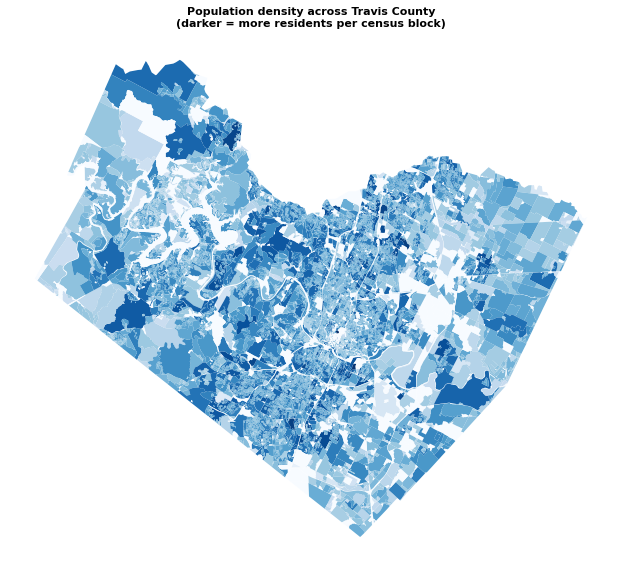

In [5]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

blocks_plot = blocks.copy()
blocks_plot['total'] = pd.to_numeric(blocks_plot['total'], errors='coerce').fillna(0)
blocks_plot['log_pop'] = np.log1p(blocks_plot['total'])

blocks_plot.plot(ax=ax, column='log_pop', cmap='Blues', edgecolor='none')
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_axis_off()
ax.set_title('Population density across Travis County\n(darker = more residents per census block)', 
             fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('../docs/images/population_density.png', dpi=150, bbox_inches='tight')
plt.show()

## Population density with old and new district lines overlaid
Shows how the same population gets carved up differently.
Orange = 2021 district lines, Red = 2026 district lines.

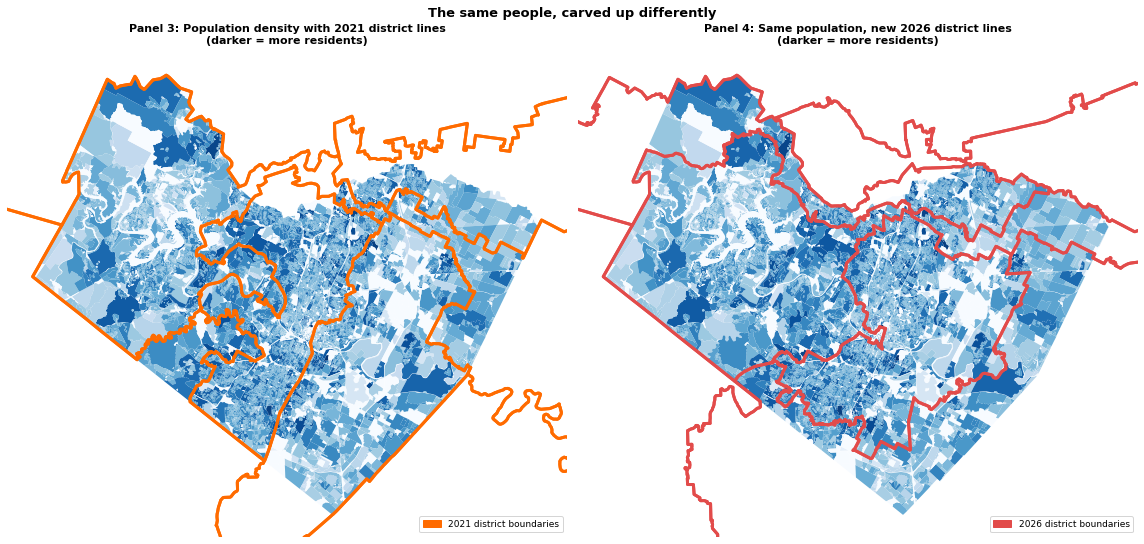

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

blocks_plot = blocks.copy()
blocks_plot['total'] = pd.to_numeric(blocks_plot['total'], errors='coerce').fillna(0)
blocks_plot['log_pop'] = np.log1p(blocks_plot['total'])

# Panel 3 — Population density with old district lines
ax3 = axes[0]
blocks_plot.plot(ax=ax3, column='log_pop', cmap='Blues', edgecolor='none')
old_travis_districts.plot(ax=ax3, color='none', edgecolor='#FF6B00', linewidth=3)
ax3.set_xlim(minx - pad_x, maxx + pad_x)
ax3.set_ylim(miny - pad_y, maxy + pad_y)
ax3.set_axis_off()
ax3.set_title('Panel 3: Population density with 2021 district lines\n(darker = more residents)',
              fontsize=11, fontweight='bold', pad=10)
old_dist_patch = mpatches.Patch(color='#FF6B00', label='2021 district boundaries')
ax3.legend(handles=[old_dist_patch], loc='lower right', fontsize=9)

# Panel 4 — Population density with new district lines
ax4 = axes[1]
blocks_plot.plot(ax=ax4, column='log_pop', cmap='Blues', edgecolor='none')
districts.plot(ax=ax4, color='none', edgecolor='#E24B4A', linewidth=3)
ax4.set_xlim(minx - pad_x, maxx + pad_x)
ax4.set_ylim(miny - pad_y, maxy + pad_y)
ax4.set_axis_off()
ax4.set_title('Panel 4: Same population, new 2026 district lines\n(darker = more residents)',
              fontsize=11, fontweight='bold', pad=10)
new_dist_patch = mpatches.Patch(color='#E24B4A', label='2026 district boundaries')
ax4.legend(handles=[new_dist_patch], loc='lower right', fontsize=9)

plt.suptitle('The same people, carved up differently',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/images/population_density_districts.png', dpi=150, bbox_inches='tight')
plt.show()

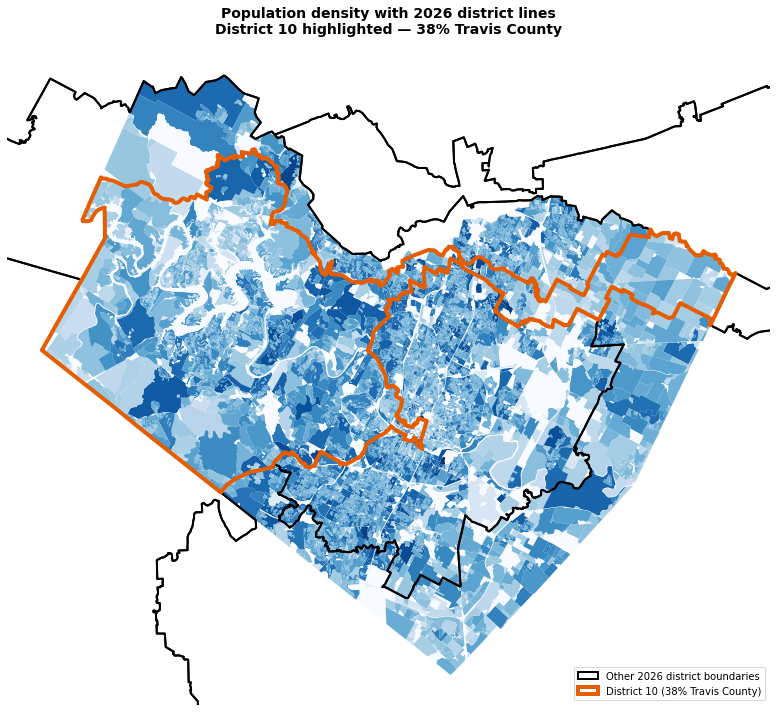

Saved population_density_district10.png


In [57]:
# Figure: Population density with 2026 district lines — District 10 highlighted
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('white')

blocks_plot = blocks.copy()
blocks_plot['total'] = pd.to_numeric(blocks_plot['total'], errors='coerce').fillna(0)
blocks_plot['log_pop'] = np.log1p(blocks_plot['total'])

blocks_plot.plot(ax=ax, column='log_pop', cmap='Blues', edgecolor='none')
districts.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

# Highlight District 10
district_10 = districts[districts['District'] == 10]
district_10.clip(travis_gdf).plot(ax=ax, color='none', edgecolor='#E65C00', linewidth=4)

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_axis_off()
ax.set_title('Population density with 2026 district lines\nDistrict 10 highlighted — 38% Travis County',
             fontsize=14, fontweight='bold', pad=12)

black_patch = mpatches.Patch(color='none', ec='black', lw=2, label='Other 2026 district boundaries')
highlighted_patch = mpatches.Patch(color='none', ec='#E65C00', lw=4, label='District 10 (38% Travis County)')
ax.legend(handles=[black_patch, highlighted_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/images/population_density_district10.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved population_density_district10.png")

## Calculate Travis County's population share of each new district
Note: raw totals sum to ~2.4M due to block overlap in spatial join.
We scale to known Travis County total (1,290,188) in the next cell.

In [7]:
# Total population per new district from our weights
travis_pop_by_district = weights.groupby('new_district_id')['fragment_population'].sum().reset_index()
travis_pop_by_district.columns = ['district', 'travis_pop']

# Total population of each full district from the statewide blocks
# We need the full district population — let's get it from the TLC data
# For now let's estimate using our known Travis County population
total_travis_pop = 1290188

print("Travis County population contribution per district:")
print(travis_pop_by_district)
print(f"\nTotal: {travis_pop_by_district['travis_pop'].sum():,.0f}")

Travis County population contribution per district:
   district  travis_pop
0        10      539926
1        11      268442
2        17       13159
3        21        2855
4        27      180707
5        31        2145
6        37     1399032

Total: 2,406,266


## Corrected Travis County population share per district
Scales raw totals to known Travis County population (1,290,188).
Each TX congressional district has ~766,987 people (2020 Census ideal).

In [8]:
# Each TX congressional district has ~766,987 people (2020 Census)
district_total_pop = 766987

# Calculate Travis County's share of each district
travis_pop_by_district = weights.groupby('new_district_id')['fragment_population'].sum().reset_index()
travis_pop_by_district.columns = ['district', 'travis_pop']

# Fix double-counting by scaling to known Travis County total
scale_factor = 1290188 / travis_pop_by_district['travis_pop'].sum()
travis_pop_by_district['travis_pop_corrected'] = travis_pop_by_district['travis_pop'] * scale_factor
travis_pop_by_district['travis_share'] = travis_pop_by_district['travis_pop_corrected'] / district_total_pop * 100

print(travis_pop_by_district[['district', 'travis_pop_corrected', 'travis_share']].round(1))

   district  travis_pop_corrected  travis_share
0        10              289496.7          37.7
1        11              143932.8          18.8
2        17                7055.6           0.9
3        21                1530.8           0.2
4        27               96891.2          12.6
5        31                1150.1           0.1
6        37              750130.8          97.8


## Figure: Travis County vote share and district influence (2026 map)
Three panels: full district extent, Travis County zoom, vote share chart.
Sorted by Travis County's share of each district (smallest to largest).
Save this as docs/images/travis_vote_share.png

<ipython-input-61-467361ae786c>:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_patches = [mpatches.Patch(color=district_color_map[row['District']][0],
<ipython-input-61-467361ae786c>:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


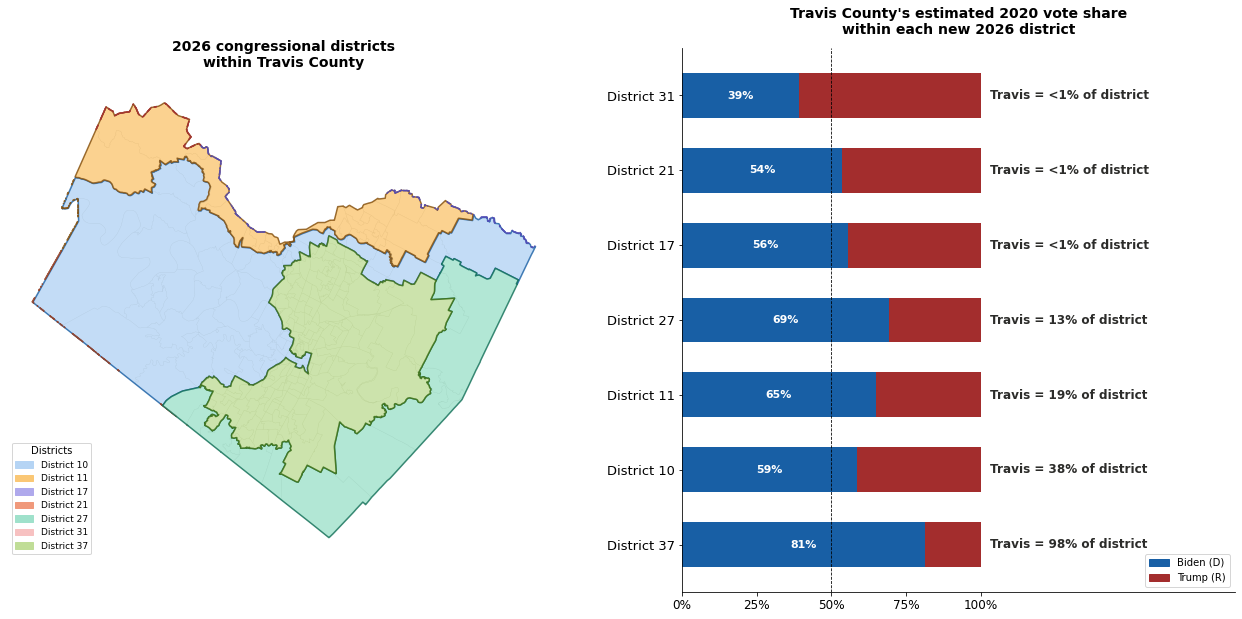

Saved travis_vote_share.png


In [61]:
# Figure: Travis County vote share — two panel version
fig, axes = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={'wspace': 0.22})
fig.patch.set_facecolor('white')

new_sorted = districts.sort_values('District').reset_index(drop=True)
travis_share = travis_pop_by_district.sort_values('travis_share', ascending=False).set_index('district')['travis_share']
districts_by_share = travis_pop_by_district.sort_values('travis_share', ascending=False)['district'].tolist()

# Panel 1 — Travis County zoom with district colors
ax1 = axes[0]
ax1.set_facecolor('white')
precincts.plot(ax=ax1, color='white', edgecolor='#B4B2A9', linewidth=0.3)
for i, (idx, row) in enumerate(new_sorted.iterrows()):
    d = row['District']
    gpd.GeoDataFrame([row], geometry='geometry', crs=new_sorted.crs).clip(
        travis_gdf
    ).plot(ax=ax1, color=district_color_map[d][0], edgecolor=district_color_map[d][1], linewidth=1.5, alpha=0.8)
ax1.set_xlim(minx - pad_x, maxx + pad_x)
ax1.set_ylim(miny - pad_y, maxy + pad_y)
ax1.set_aspect('equal')
ax1.set_axis_off()
ax1.set_title('2026 congressional districts\nwithin Travis County',
              fontsize=14, fontweight='bold', pad=14)
legend_patches = [mpatches.Patch(color=district_color_map[row['District']][0],
                  edgecolor=district_color_map[row['District']][1],
                  label=f"District {row['District']}")
                  for i, (_, row) in enumerate(new_sorted.iterrows())]
ax1.legend(handles=legend_patches, loc='lower left', fontsize=9, title='Districts', title_fontsize=10)

# Panel 2 — Vote share chart
ax2 = axes[1]
ax2.set_facecolor('white')
biden = results[results['candidate'] == 'Biden'].set_index('new_district_id')['estimated_votes']
trump = results[results['candidate'] == 'Trump'].set_index('new_district_id')['estimated_votes']
total = {d: biden[d] + trump[d] for d in districts_by_share}
biden_share_pct = {d: biden[d] / total[d] * 100 for d in districts_by_share}
trump_share_pct = {d: trump[d] / total[d] * 100 for d in districts_by_share}

y = range(len(districts_by_share))
for i, d in enumerate(districts_by_share):
    ax2.barh(i, biden_share_pct[d], color='#185FA5', height=0.6)
    ax2.barh(i, trump_share_pct[d], left=biden_share_pct[d], color='#A32D2D', height=0.6)
    ax2.text(biden_share_pct[d] / 2, i, f"{biden_share_pct[d]:.0f}%",
             ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    share_label = "<1%" if travis_share[d] < 1 else f"{travis_share[d]:.0f}%"
    ax2.text(103, i, f"Travis = {share_label} of district",
             ha='left', va='center', fontsize=12, color='#2C2C2A', fontweight='bold')

ax2.set_yticks(list(y))
ax2.set_yticklabels([f'District {d}' for d in districts_by_share], fontsize=13)
ax2.axvline(x=50, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlim(0, 185)
ax2.set_xticks([0, 25, 50, 75, 100])
ax2.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax2.tick_params(axis='x', labelsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title("Travis County's estimated 2020 vote share\nwithin each new 2026 district",
              fontsize=14, fontweight='bold', pad=14)
biden_patch = mpatches.Patch(color='#185FA5', label='Biden (D)')
trump_patch = mpatches.Patch(color='#A32D2D', label='Trump (R)')
ax2.legend(handles=[biden_patch, trump_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/images/travis_vote_share.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved travis_vote_share.png")

## Calculate Travis County's population share of each OLD district (2021 map)
Same logic as the new district calculation but applied to PlanC2193.
Key finding: District 35 was 38% Travis County — the key competitive district.

In [10]:
# Spatial join blocks to old districts
old_districts_join = gpd.sjoin(
    blocks[['SCTBKEY', 'total', 'geometry']],
    old_travis_districts[['District', 'geometry']],
    how='left',
    predicate='intersects'
)

old_travis_pop = old_districts_join.groupby('District')['total'].sum().reset_index()
old_travis_pop.columns = ['district', 'travis_pop']

# Scale to known Travis County total
scale_factor = 1290188 / old_travis_pop['travis_pop'].sum()
old_travis_pop['travis_pop_corrected'] = old_travis_pop['travis_pop'] * scale_factor
old_travis_pop['travis_share'] = old_travis_pop['travis_pop_corrected'] / 766987 * 100

print(old_travis_pop[['district', 'travis_share']].round(1))

   district  travis_share
0        10          25.7
1        17           9.2
2        21           5.0
3        27           0.3
4        31           0.6
5        35          38.1
6        37          89.2


## Figure: How redistricting changed Travis County's influence (2021 vs 2026)
Two rows: old map (2021) and new map (2026).
Each row shows full district extent, Travis County zoom, and population share chart.
Save this as docs/images/redistricting_comparison.png

<ipython-input-12-714f049eab14>:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_patches = [mpatches.Patch(color=colors[i], edgecolor=edge_colors[i],
<ipython-input-12-714f049eab14>:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_patches = [mpatches.Patch(color=colors[i], edgecolor=edge_colors[i],


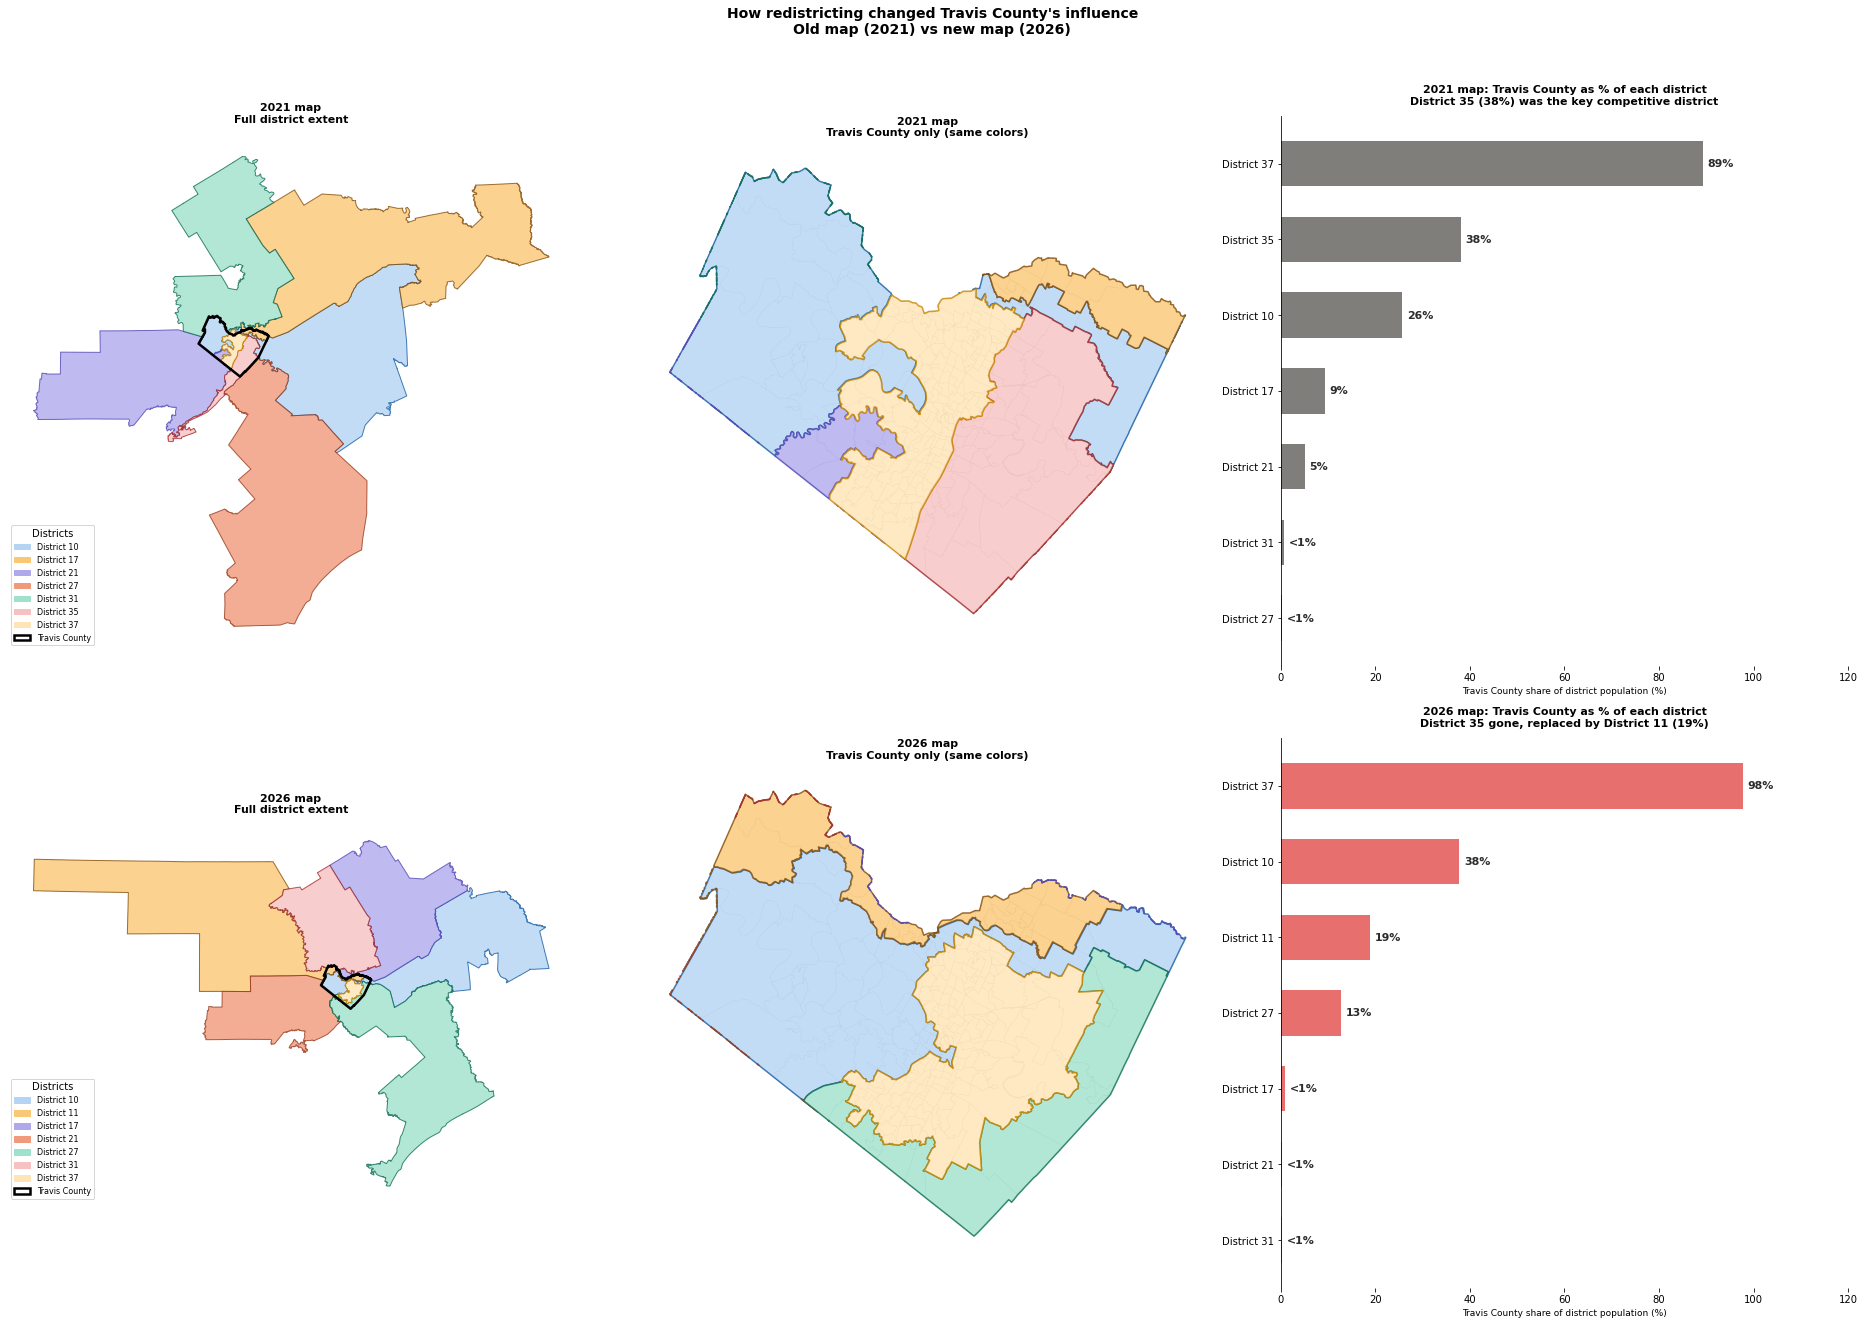

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(26, 18))
fig.patch.set_facecolor('white')

old_sorted = old_travis_districts.sort_values('District').reset_index(drop=True)
old_share = old_travis_pop.sort_values('travis_share', ascending=True).set_index('district')['travis_share']
old_districts_by_share = old_travis_pop.sort_values('travis_share', ascending=True)['district'].tolist()

new_sorted = districts.sort_values('District').reset_index(drop=True)
new_share = travis_pop_by_district.sort_values('travis_share', ascending=True).set_index('district')['travis_share']
new_districts_by_share = travis_pop_by_district.sort_values('travis_share', ascending=True)['district'].tolist()

colors =      ['#B5D4F4', '#FAC775', '#AFA9EC', '#F0997B', '#9FE1CB', '#F7C1C1', '#FFE4B5']
edge_colors = ['#185FA5', '#854F0B', '#534AB7', '#993C1D', '#0F6E56', '#A32D2D', '#CC8800']

travis_union = precincts.unary_union
travis_gdf = gpd.GeoDataFrame([{'geometry': travis_union}], geometry='geometry', crs=precincts.crs)

def make_row(ax_full, ax_zoom, ax_chart, sorted_df, share_data, districts_by_share, title_prefix, line_color):

    # Panel 1 — Full extent
    ax_full.set_facecolor('white')
    for i, (idx, row) in enumerate(sorted_df.iterrows()):
        gpd.GeoDataFrame([row], geometry='geometry', crs=sorted_df.crs).plot(
            ax=ax_full, color=colors[i], edgecolor=edge_colors[i], linewidth=1, alpha=0.8)
    precincts.dissolve().plot(ax=ax_full, color='none', edgecolor='black', linewidth=2.5)
    ax_full.set_axis_off()
    ax_full.set_title(f'{title_prefix}\nFull district extent',
                      fontsize=11, fontweight='bold', pad=10)
    legend_patches = [mpatches.Patch(color=colors[i], edgecolor=edge_colors[i],
                      label=f"District {row['District']}")
                      for i, (_, row) in enumerate(sorted_df.iterrows())]
    legend_patches.append(mpatches.Patch(color='none', ec='black', lw=2.5, label='Travis County'))
    ax_full.legend(handles=legend_patches, loc='lower left', fontsize=8, title='Districts')

    # Panel 2 — Travis County zoom (fixed orientation)
    ax_zoom.set_facecolor('white')
    precincts.plot(ax=ax_zoom, color='white', edgecolor='#B4B2A9', linewidth=0.3)
    for i, (idx, row) in enumerate(sorted_df.iterrows()):
        gpd.GeoDataFrame([row], geometry='geometry', crs=sorted_df.crs).clip(
            travis_gdf
        ).plot(ax=ax_zoom, color=colors[i], edgecolor=edge_colors[i], linewidth=1.5, alpha=0.8)
    ax_zoom.set_xlim(minx - pad_x, maxx + pad_x)
    ax_zoom.set_ylim(miny - pad_y, maxy + pad_y)
    ax_zoom.set_aspect('equal')
    ax_zoom.set_axis_off()
    ax_zoom.set_title(f'{title_prefix}\nTravis County only (same colors)',
                      fontsize=11, fontweight='bold', pad=10)

    # Panel 3 — Share chart (no dashed line, added note)
    ax_chart.set_facecolor('white')
    y = range(len(districts_by_share))
    for i, d in enumerate(districts_by_share):
        share_label = "<1%" if share_data[d] < 1 else f"{share_data[d]:.0f}%"
        ax_chart.barh(i, share_data[d], color=line_color, height=0.6, alpha=0.8)
        ax_chart.text(share_data[d] + 1, i, share_label,
                     ha='left', va='center', fontsize=11, color='#2C2C2A', fontweight='bold')
    ax_chart.set_yticks(list(y))
    ax_chart.set_yticklabels([f'District {d}' for d in districts_by_share], fontsize=10)
    ax_chart.set_xlim(0, 120)
    ax_chart.spines['top'].set_visible(False)
    ax_chart.spines['right'].set_visible(False)
    ax_chart.spines['bottom'].set_visible(False)
    ax_chart.set_xlabel('Travis County share of district population (%)', fontsize=9)

    if '2021' in title_prefix:
        ax_chart.set_title('2021 map: Travis County as % of each district\nDistrict 35 (38%) was the key competitive district',
                           fontsize=11, fontweight='bold', pad=12)
    else:
        ax_chart.set_title('2026 map: Travis County as % of each district\nDistrict 35 gone, replaced by District 11 (19%)',
                           fontsize=11, fontweight='bold', pad=12)

# Top row — old map
make_row(axes[0,0], axes[0,1], axes[0,2],
         old_sorted, old_share, old_districts_by_share,
         '2021 map', '#5F5E5A')

# Bottom row — new map
make_row(axes[1,0], axes[1,1], axes[1,2],
         new_sorted, new_share, new_districts_by_share,
         '2026 map', '#E24B4A')

plt.suptitle('How redistricting changed Travis County\'s influence\nOld map (2021) vs new map (2026)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/images/redistricting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<ipython-input-44-44c59251457a>:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


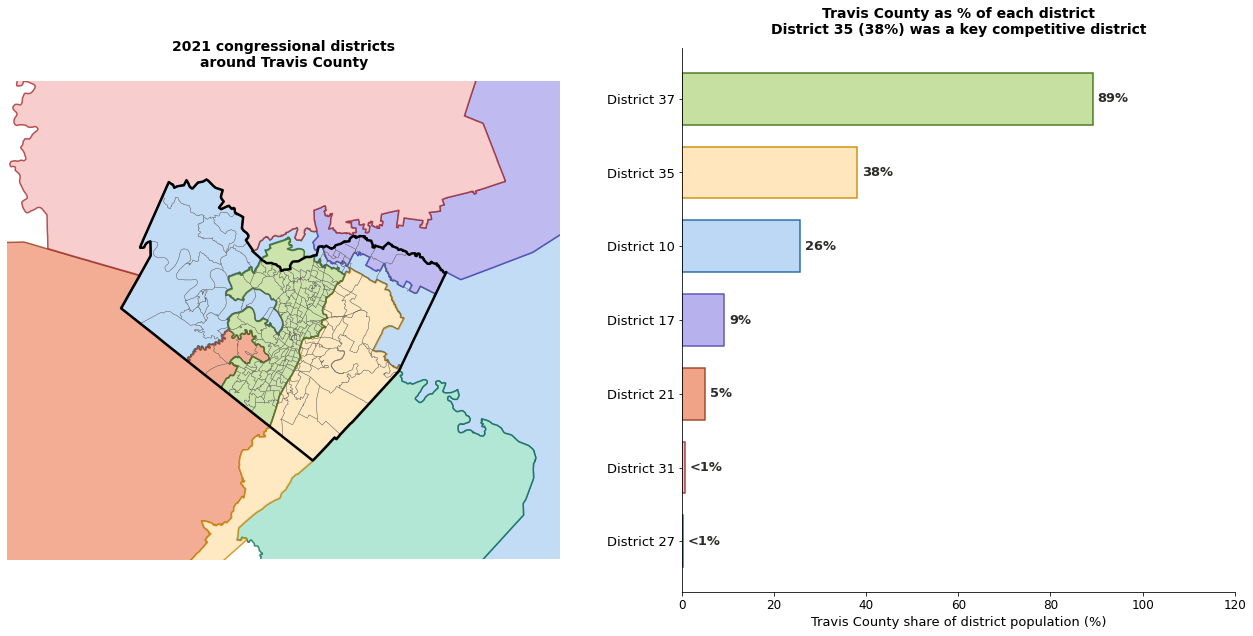

Saved redistricting_2021.png


In [44]:
# Figure A — 2021 map (two panel version)
fig, axes = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={'wspace': 0.22})
fig.patch.set_facecolor('white')

district_color_map = {
    10: ('#B5D4F4', '#185FA5'),
    11: ('#FAC775', '#854F0B'),
    17: ('#AFA9EC', '#534AB7'),
    21: ('#F0997B', '#993C1D'),
    27: ('#9FE1CB', '#0F6E56'),
    31: ('#F7C1C1', '#A32D2D'),
    35: ('#FFE4B5', '#CC8800'),
    37: ('#C0DD97', '#3B6D11')
}

old_sorted = old_travis_districts.sort_values('District').reset_index(drop=True)
old_share = old_travis_pop.sort_values('travis_share', ascending=True).set_index('district')['travis_share']
old_districts_by_share = old_travis_pop.sort_values('travis_share', ascending=True)['district'].tolist()
travis_union = precincts.unary_union
travis_gdf = gpd.GeoDataFrame([{'geometry': travis_union}], geometry='geometry', crs=precincts.crs)

# Extended bounds — show a bit outside Travis County
ext_pad_x = (maxx - minx) * 0.35
ext_pad_y = (maxy - miny) * 0.35

# Panel 1 — Travis County with slight extension
ax1 = axes[0]
ax1.set_facecolor('white')
for i, (idx, row) in enumerate(old_sorted.iterrows()):
    d = row['District']
    gpd.GeoDataFrame([row], geometry='geometry', crs=old_sorted.crs).plot(
        ax=ax1, color=district_color_map[d][0], edgecolor=district_color_map[d][1], linewidth=1.5, alpha=0.8)
precincts.plot(ax=ax1, color='none', edgecolor='#5F5E5A', linewidth=0.3)
precincts.dissolve().plot(ax=ax1, color='none', edgecolor='black', linewidth=2.5)

ax1.set_xlim(minx - ext_pad_x, maxx + ext_pad_x)
ax1.set_ylim(miny - ext_pad_y, maxy + ext_pad_y)
#ax1.set_aspect('equal')
ax1.set_axis_off()
ax1.set_title('2021 congressional districts\naround Travis County', 
              fontsize=14, fontweight='bold', pad=14)

# Panel 2 — Bar chart
ax2 = axes[1]
ax2.set_facecolor('white')
y = range(len(old_districts_by_share))
for i, d in enumerate(old_districts_by_share):
    share_label = "<1%" if old_share[d] < 1 else f"{old_share[d]:.0f}%"
    ax2.barh(i, old_share[d], color=district_color_map[d][0],
             edgecolor=district_color_map[d][1], height=0.7, alpha=0.9, linewidth=1.5)
    ax2.text(old_share[d] + 1, i, share_label,
             ha='left', va='center', fontsize=13, color='#2C2C2A', fontweight='bold')
ax2.set_yticks(list(y))
ax2.set_yticklabels([f'District {d}' for d in old_districts_by_share], fontsize=13)
ax2.set_xlim(0, 120)
ax2.tick_params(axis='x', labelsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(True)
ax2.tick_params(axis='x', labelsize=12)
ax2.set_xlabel('Travis County share of district population (%)', fontsize=13)
ax2.set_title('Travis County as % of each district\nDistrict 35 (38%) was a key competitive district',
              fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('../docs/images/redistricting_2021.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved redistricting_2021.png")

<ipython-input-47-89fc671b0a5f>:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


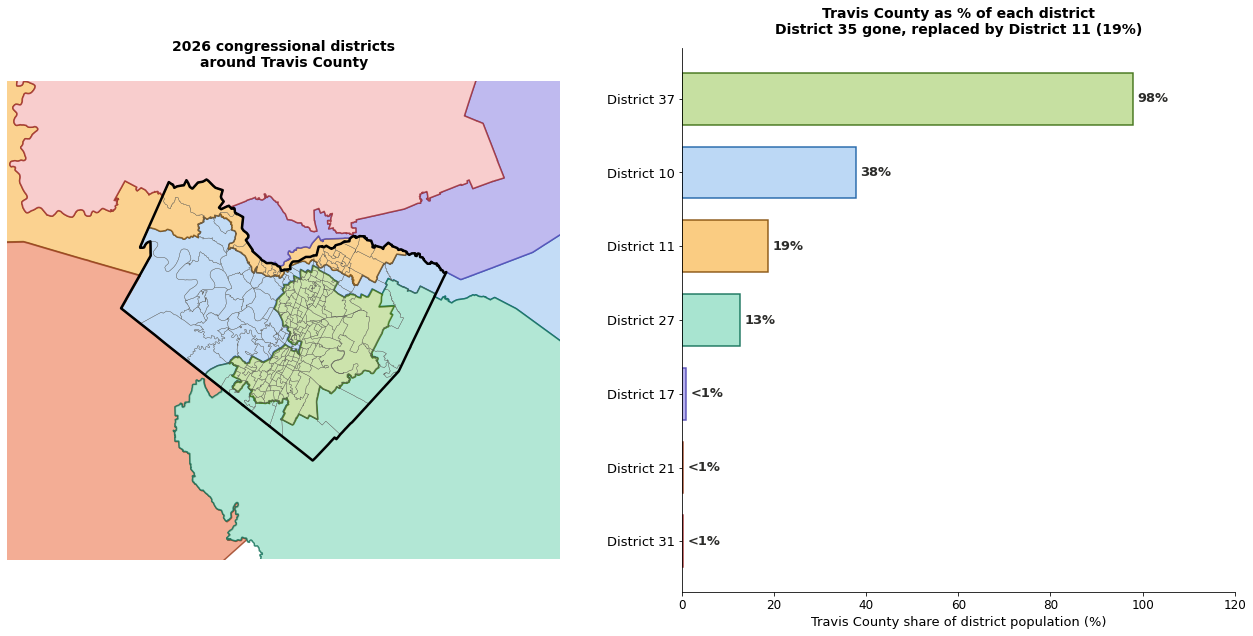

Saved redistricting_2026.png


In [47]:
# Figure B — 2026 map (two panel version)
fig, axes = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={'wspace': 0.22})
fig.patch.set_facecolor('white')

new_sorted = districts.sort_values('District').reset_index(drop=True)
new_share = travis_pop_by_district.sort_values('travis_share', ascending=True).set_index('district')['travis_share']
new_districts_by_share = travis_pop_by_district.sort_values('travis_share', ascending=True)['district'].tolist()

# Panel 1 — Travis County with slight extension
ax1 = axes[0]
ax1.set_facecolor('white')
for i, (idx, row) in enumerate(new_sorted.iterrows()):
    d = row['District']
    gpd.GeoDataFrame([row], geometry='geometry', crs=new_sorted.crs).plot(
        ax=ax1, color=district_color_map[d][0], edgecolor=district_color_map[d][1], linewidth=1.5, alpha=0.8)
precincts.plot(ax=ax1, color='none', edgecolor='#5F5E5A', linewidth=0.3)
precincts.dissolve().plot(ax=ax1, color='none', edgecolor='black', linewidth=2.5)
ax1.set_xlim(minx - ext_pad_x, maxx + ext_pad_x)
ax1.set_ylim(miny - ext_pad_y, maxy + ext_pad_y)
ax1.set_aspect('equal')
ax1.set_axis_off()
ax1.set_title('2026 congressional districts\naround Travis County',
              fontsize=14, fontweight='bold', pad=14)

# Panel 2 — Bar chart
ax2 = axes[1]
ax2.set_facecolor('white')
y = range(len(new_districts_by_share))
for i, d in enumerate(new_districts_by_share):
    share_label = "<1%" if new_share[d] < 1 else f"{new_share[d]:.0f}%"
    ax2.barh(i, new_share[d], color=district_color_map[d][0],
             edgecolor=district_color_map[d][1], height=0.7, alpha=0.9, linewidth=1.5)
    ax2.text(new_share[d] + 1, i, share_label,
             ha='left', va='center', fontsize=13, color='#2C2C2A', fontweight='bold')
ax2.set_yticks(list(y))
ax2.set_yticklabels([f'District {d}' for d in new_districts_by_share], fontsize=13)
ax2.set_xlim(0, 120)
ax2.tick_params(axis='x', labelsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlabel('Travis County share of district population (%)', fontsize=13)
ax2.set_title('Travis County as % of each district\nDistrict 35 gone, replaced by District 11 (19%)',
              fontsize=14, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('../docs/images/redistricting_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved redistricting_2026.png")